# 6. Позиционные кодирования

**Цель:** Понять, почему трансформерам нужна информация о позиции токенов, реализовать синусоидальные и обучаемые позиционные кодирования, сравнить подходы.

---

## Sinusoidal PE Formula

$$
PE_{(pos,2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$
$$
PE_{(pos,2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

where $pos$ is the token position, $i$ is the dimension index, and $d_{model}$ is the embedding dimension.


In [1]:
# Imports: logging, torch, numpy, matplotlib
# PE is the only source of order info in transformers — without it self-attn is permutation-invariant
import sys, os, logging, math
LOG_LEVEL = os.getenv("LOG_LEVEL", "DEBUG")
logging.basicConfig(level=getattr(logging, LOG_LEVEL), format="%(asctime)s [%(levelname)s] %(name)s: %(message)s", stream=sys.stderr)
log = logging.getLogger("positional")

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
log.info("Using device: %s", device)


2026-05-31 19:25:47,323 [DEBUG] matplotlib: matplotlib data path: /Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data
2026-05-31 19:25:47,332 [DEBUG] matplotlib: CONFIGDIR=/Users/demanbudaev/.matplotlib
2026-05-31 19:25:47,338 [DEBUG] matplotlib: interactive is False
2026-05-31 19:25:47,338 [DEBUG] matplotlib: platform is darwin
2026-05-31 19:25:47,371 [DEBUG] matplotlib: CACHEDIR=/Users/demanbudaev/.matplotlib
2026-05-31 19:25:47,374 [DEBUG] matplotlib.font_manager: Using fontManager instance from /Users/demanbudaev/.matplotlib/fontlist-v390.json
2026-05-31 19:25:47,514 [INFO] positional: Using device: mps


## 6.1 Проблема: Permutation Invariance

**В чём проблема?**
- Attention вычисляет взвешенную сумму на основе попарных взаимодействий
- Если переставить токены, attention weights переставятся соответственно
- Модель не знает, что "яблоко съело" и "съело яблоко" — разные вещи

**Решение:** Добавить информацию о позиции токена к его эмбеддингу.

Два основных подхода:
1. **Синусоидальные PE** (Vaswani et al., 2017) — фиксированные, не обучаются
2. **Обучаемые PE** (BERT, GPT) — nn.Embedding(max_len, d_model)

## 6.2 Синусоидальные позиционные кодирования

**Формулы (Vaswani et al.):**
$$
PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right) \\
PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

**Свойства:**
- Каждая размерность кодирует свою частоту
- Плавное изменение по позиции — модель может экстраполировать
- Для любого смещения k, PE(pos+k) можно выразить как линейную функцию от PE(pos)

In [2]:
log.debug("Implementing sinusoidal positional encodings")

# Each frequency captures a different scale of position: low freq = global, high freq = local
# sin/cos at different frequencies: each pair (2i, 2i+1) encodes one frequency
# Low frequencies (small i) -> slow changes, encode long-range structure
# High frequencies (large i) -> fast oscillations, encode local/nearby patterns
# PE(pos+k) is a linear function of PE(pos) via sin(a+b)/cos(a+b) identities (see Derivation)
def sinusoidal_pe(max_len, d_model):
    """
    Generates sinusoidal positional encodings.
    
    Args:
        max_len: maximum sequence length
        d_model: model dimension
    
    Returns:
        pe: (max_len, d_model)
    """
    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)  # (max_len, 1)
    
    # Frequencies: 10000^(2i/d_model) for i = 0, 1, ..., d_model/2 - 1
    # 10000 is the base scale; d_model controls frequency growth rate with i
    div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))
    
    pe[:, 0::2] = torch.sin(position * div_term)  # even indices — sin
    pe[:, 1::2] = torch.cos(position * div_term)  # odd indices — cos
    
    log.debug("Sinusoidal PE shape: %s", pe.shape)
    return pe

max_len, d_model = 100, 32
pe_sinusoidal = sinusoidal_pe(max_len, d_model)
print(f"Sinusoidal PE shape: {pe_sinusoidal.shape}")
print(f"PE[0, :8]:  {pe_sinusoidal[0, :8].numpy().round(4)}")
print(f"PE[1, :8]:  {pe_sinusoidal[1, :8].numpy().round(4)}")
log.info("Sinusoidal PE generated")


2026-05-31 19:26:32,027 [DEBUG] positional: Implementing sinusoidal positional encodings
2026-05-31 19:26:32,034 [DEBUG] positional: Sinusoidal PE shape: torch.Size([100, 32])
2026-05-31 19:26:32,036 [INFO] positional: Sinusoidal PE generated


Sinusoidal PE shape: torch.Size([100, 32])
PE[0, :8]:  [0. 1. 0. 1. 0. 1. 0. 1.]
PE[1, :8]:  [0.8415 0.5403 0.5332 0.846  0.311  0.9504 0.1769 0.9842]


## 6.3 Визуализация синусоидальных PE

Heatmap показывает, как разные размерности кодируют позицию на разных частотах.

2026-05-31 19:27:18,788 [DEBUG] positional: Visualizing sinusoidal PE heatmap
2026-05-31 19:27:18,804 [DEBUG] matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-31 19:27:18,809 [DEBUG] matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-05-31 19:27:18,818 [DEBUG] matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-05-31 19:27:18,819 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2026-05-31 19:27:18,820 [DEBUG] matplotlib.font_manager: findfont: score(FontEntry(fname='/Users/demanbudaev/PycharmProjects/Ashat_AI/.venv/lib/python3.9/site-packages/matplotlib/mpl

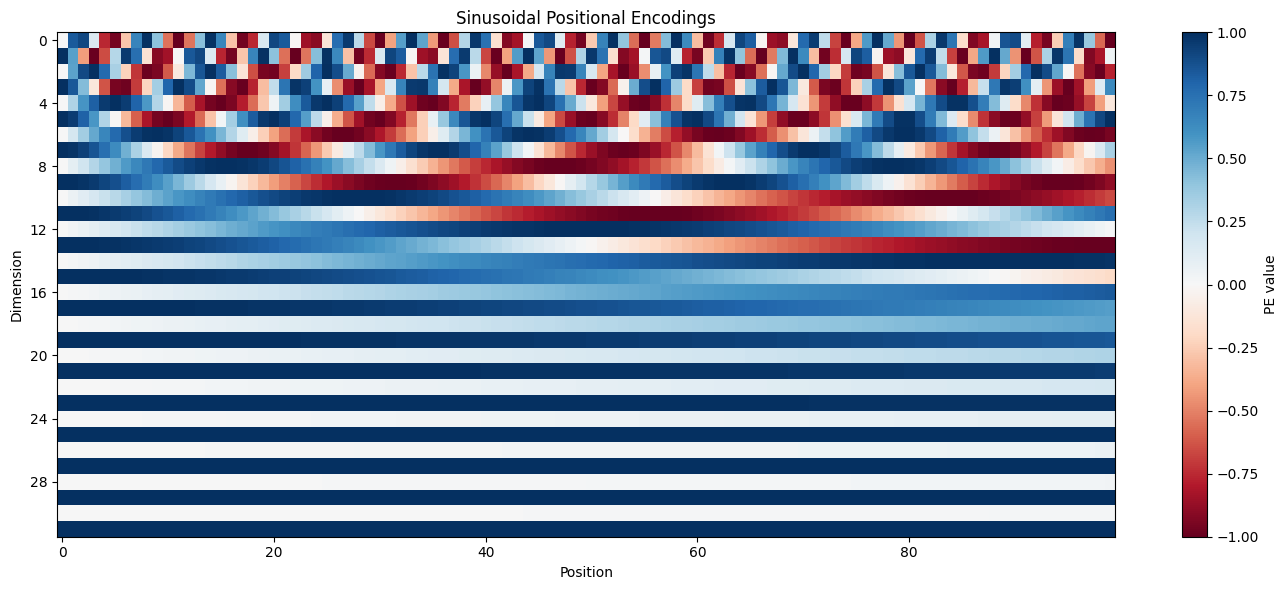

2026-05-31 19:27:19,394 [INFO] positional: PE heatmap plotted


In [3]:
log.debug("Visualizing sinusoidal PE heatmap")

# Heatmap: X=position, Y=dimension (low freq at top, high freq at bottom)
# Low-frequency dims change slowly — encode global/coarse structure
# High-frequency dims oscillate quickly — encode local/fine-grained patterns
# The model can distinguish far vs near at multiple scales simultaneously
plt.figure(figsize=(14, 6))
plt.imshow(pe_sinusoidal.T, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='PE value')
plt.xlabel('Position')
plt.ylabel('Dimension')
plt.title('Sinusoidal Positional Encodings')
plt.yticks(range(0, d_model, 4))
plt.tight_layout()
plt.show()
log.info("PE heatmap plotted")


2026-05-31 19:28:20,232 [DEBUG] positional: Plotting selected dimension curves


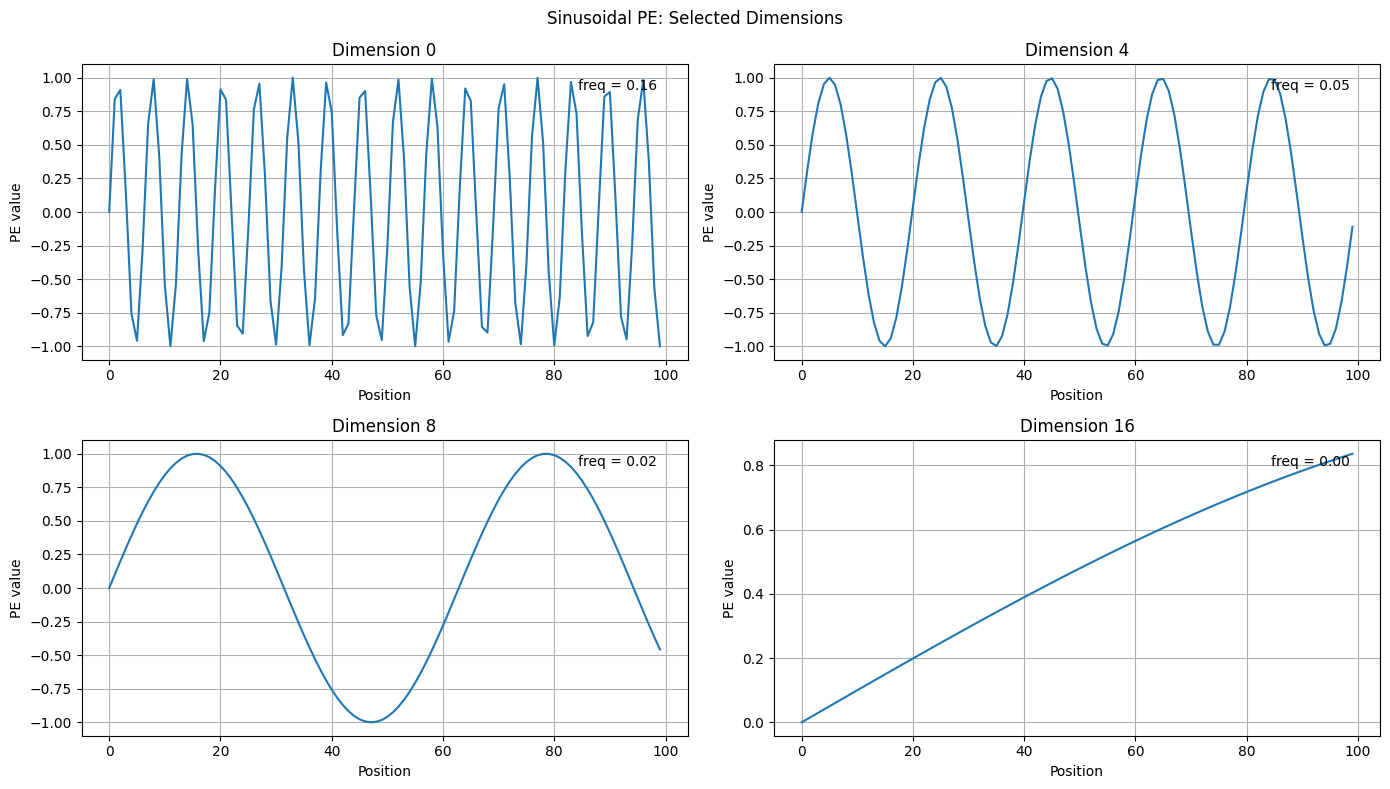

2026-05-31 19:28:20,453 [INFO] positional: Dimension curves plotted


In [4]:
log.debug("Plotting selected dimension curves")

# Individual dims: dim 0 = lowest freq (longest period, encodes sentence-level position)
# dim 16 = ~2x frequency; dim 4, 8 = intermediate
# Higher freq = smaller receptive field over positions (local patterns)
# The combination of all frequencies gives each position a unique signature
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
dims_to_plot = [0, 4, 8, 16]
for ax, dim in zip(axes.flat, dims_to_plot):
    ax.plot(pe_sinusoidal[:, dim].numpy())
    ax.set_title(f'Dimension {dim}')
    ax.set_xlabel('Position')
    ax.set_ylabel('PE value')
    ax.grid(True)
    freq = 10000 ** (-dim / d_model) / (2 * math.pi)
    ax.text(0.95, 0.95, f'freq = {freq:.2f}', transform=ax.transAxes, ha='right', va='top', fontsize=10)
plt.suptitle('Sinusoidal PE: Selected Dimensions')
plt.tight_layout()
plt.show()
log.info("Dimension curves plotted")


## Derivation: why sin/cos preserve relative distance

Thanks to trigonometric identities, PE(pos+k) is a **linear function** of PE(pos):

$$
\begin{aligned}
PE_{(pos+k, 2i)} &= \sin\left(\frac{pos+k}{10000^{2i/d_{model}}}\right) \\
&= \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right) \cos\left(\frac{k}{10000^{2i/d_{model}}}\right) + \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right) \sin\left(\frac{k}{10000^{2i/d_{model}}}\right) \\
&= PE_{(pos, 2i)} \cdot \cos\left(\frac{k}{\omega_i}\right) + PE_{(pos, 2i+1)} \cdot \sin\left(\frac{k}{\omega_i}\right)
\end{aligned}
$$

Similarly for cosine:

$$
\begin{aligned}
PE_{(pos+k, 2i+1)} &= PE_{(pos, 2i+1)} \cdot \cos\left(\frac{k}{\omega_i}\right) - PE_{(pos, 2i)} \cdot \sin\left(\frac{k}{\omega_i}\right)
\end{aligned}
$$

where $\omega_i = 10000^{2i/d_{model}}$.

This means for every offset $k$ there is a rotation matrix $T_k$ such that:

$$
PE(pos+k) = T_k \cdot PE(pos)
$$

The model can thus **learn to use relative positions**: attention can compute not just
which tokens to attend to but also at what distance.
Linearity is key: without it the model would have to memorise every pair (pos, pos+k) separately.


## 6.4 Класс PositionalEncoding

Оборачиваем PE в nn.Module для использования в трансформере.

In [5]:
log.debug("Implementing PositionalEncoding module")

# PE is added element-wise to embeddings at the bottom of encoder/decoder
# This is equivalent to concatenating a position feature to each token vector
# sin/cos preserve relative positions: PE(pos+k) = T_k @ PE(pos) — a rotation matrix
# This lets attention compute offsets between tokens, not just absolute positions
# Dropout is applied after addition for regularisation
class PositionalEncoding(nn.Module):
    """Sinusoidal positional encodings (Vaswani et al.)."""
    
    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = sinusoidal_pe(max_len, d_model)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
        
        log.debug("PositionalEncoding: max_len=%d, d_model=%d", max_len, d_model)
    
    def forward(self, x):
        """x: (batch, seq_len, d_model)"""
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

pos_encoder = PositionalEncoding(d_model=32, max_len=100)
log.info("PositionalEncoding module created")


2026-05-31 19:28:57,295 [DEBUG] positional: Implementing PositionalEncoding module
2026-05-31 19:28:57,299 [DEBUG] positional: Sinusoidal PE shape: torch.Size([100, 32])
2026-05-31 19:28:57,300 [DEBUG] positional: PositionalEncoding: max_len=100, d_model=32
2026-05-31 19:28:57,300 [INFO] positional: PositionalEncoding module created


## 6.5 Обучаемые позиционные эмбеддинги (BERT-style)

Альтернатива: nn.Embedding(max_len, d_model), где веса обучаются в процессе тренировки.

In [6]:
log.debug("Implementing learnable positional embeddings")

# Learnable PE: nn.Embedding(max_len, d_model) — each position vector is a free param
# Pro: model learns optimal encoding for the specific task
# Con: max_len is fixed — cannot handle longer sequences at inference
# PE is added to embeddings the same way: x = x + pe (element-wise)
class LearnablePositionalEmbedding(nn.Module):
    """Learnable positional embeddings (BERT-style)."""
    
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        self.embedding = nn.Embedding(max_len, d_model)
        
        log.debug("LearnablePositionalEmbedding: max_len=%d, d_model=%d, params=%d",
                  max_len, d_model, max_len * d_model)
    
    def forward(self, x):
        """x: (batch, seq_len, d_model)"""
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)  # (1, seq_len)
        pe = self.embedding(positions)  # (1, seq_len, d_model)
        x = x + pe
        return self.dropout(x)

learnable_pe = LearnablePositionalEmbedding(d_model=32, max_len=100)
log.info("Learnable PositionalEmbedding created")


2026-05-31 19:29:08,774 [DEBUG] positional: Implementing learnable positional embeddings
2026-05-31 19:29:08,779 [DEBUG] positional: LearnablePositionalEmbedding: max_len=100, d_model=32, params=3200
2026-05-31 19:29:08,780 [INFO] positional: Learnable PositionalEmbedding created


2026-05-31 19:29:12,926 [DEBUG] positional: Visualizing learned PE after initialization
2026-05-31 19:29:13,054 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x10d6cf280>
2026-05-31 19:29:13,067 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x10d4cc1f0>


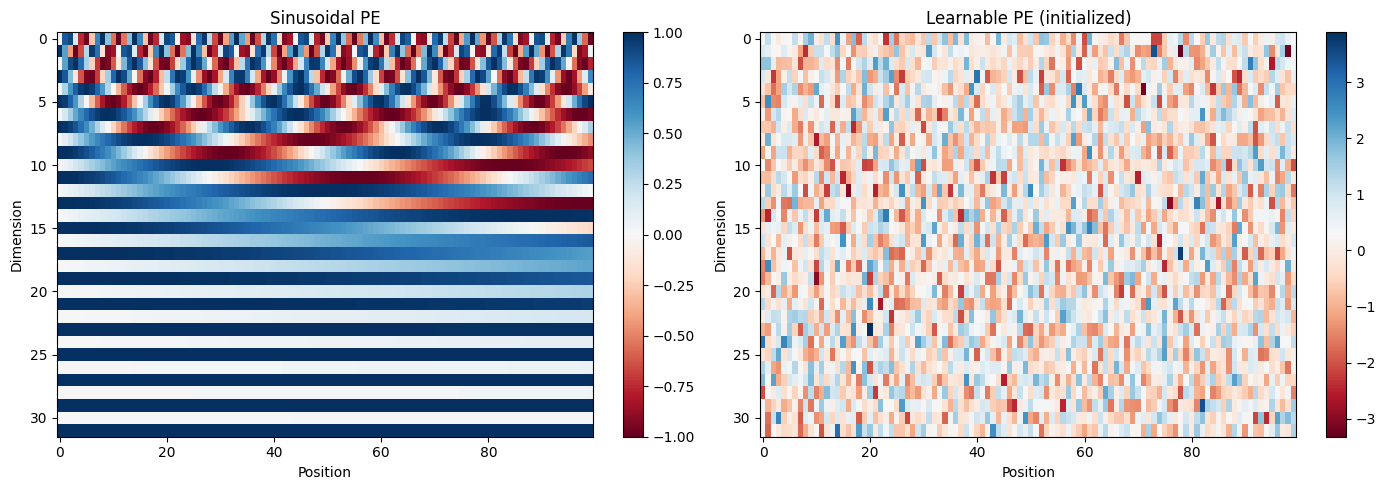

2026-05-31 19:29:13,214 [INFO] positional: PE comparison plotted


In [7]:
log.debug("Visualizing learned PE after initialization")

# Left: sinusoidal PE (deterministic, smooth, structured across frequencies)
# Right: learnable PE (random init — uniform or normal)
# During training, learnable PE converges to a structure resembling sin/cos
# Sinusoidal PE: zero parameters + unlimited sequence length support
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.imshow(pe_sinusoidal.T, cmap='RdBu', aspect='auto', vmin=-1, vmax=1)
plt.title('Sinusoidal PE')
plt.xlabel('Position')
plt.ylabel('Dimension')
plt.colorbar(fraction=0.046)

plt.subplot(1, 2, 2)
learned_pe = learnable_pe.embedding.weight.detach().numpy().T
plt.imshow(learned_pe, cmap='RdBu', aspect='auto')
plt.title('Learnable PE (initialized)')
plt.xlabel('Position')
plt.ylabel('Dimension')
plt.colorbar(fraction=0.046)

plt.tight_layout()
plt.show()
log.info("PE comparison plotted")


## 6.6 Демонстрация: как PE влияет на внимание

Проверим, как attention меняется с и без позиционных кодирований.

2026-05-31 19:29:30,288 [DEBUG] positional: Demonstrating effect of PE on attention
2026-05-31 19:29:30,304 [DEBUG] positional: Sinusoidal PE shape: torch.Size([10, 16])
2026-05-31 19:29:30,324 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x10d8fb7f0>
2026-05-31 19:29:30,332 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x10d943280>


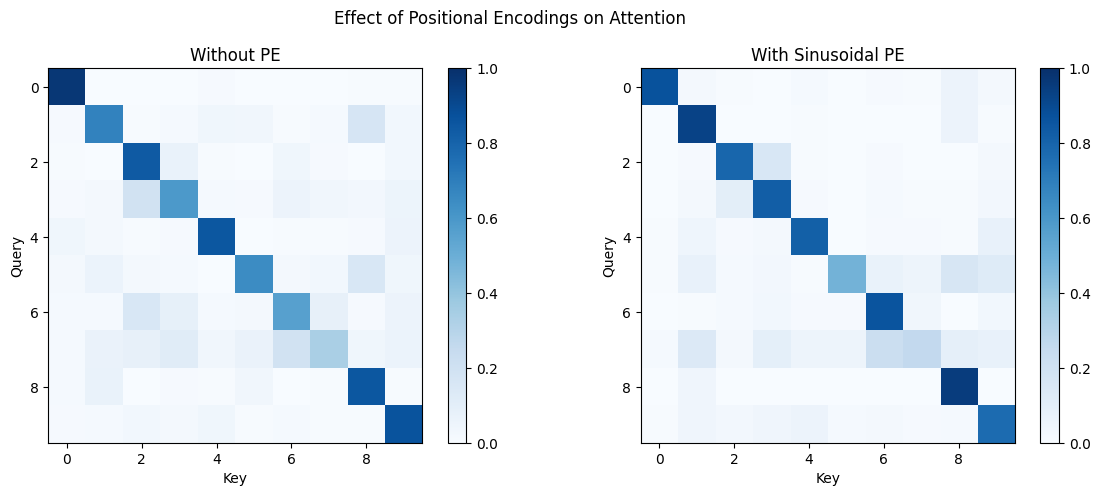

2026-05-31 19:29:30,448 [INFO] positional: PE effect demonstration complete, max diff=0.3042


Max attention difference: 0.3042


In [8]:
log.debug("Demonstrating effect of PE on attention")

# Self-attn WITHOUT PE: attention matrix is nearly uniform — all positions are equal
# Self-attn WITH PE: diagonal/nearby pairs get higher weight
# The difference shows what order information PE injected
# Low-freq components affect global attn structure; high-freq affect local patterns
d_model, seq_len = 16, 10

# Simple single-head attention for demonstration
def simple_attention(Q, K, V):
    scores = Q @ K.transpose(-2, -1) / math.sqrt(Q.size(-1))
    attn = F.softmax(scores, dim=-1)
    return attn @ V, attn

torch.manual_seed(42)
embeddings = torch.randn(1, seq_len, d_model)

# Without PE
output_no_pe, attn_no_pe = simple_attention(embeddings, embeddings, embeddings)

# With PE
pe = sinusoidal_pe(seq_len, d_model).unsqueeze(0)
embeddings_with_pe = embeddings + pe
output_with_pe, attn_with_pe = simple_attention(embeddings_with_pe, embeddings_with_pe, embeddings_with_pe)

# Compare attention matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im0 = axes[0].imshow(attn_no_pe[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('Without PE')
axes[0].set_xlabel('Key')
axes[0].set_ylabel('Query')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(attn_with_pe[0].detach().numpy(), cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('With Sinusoidal PE')
axes[1].set_xlabel('Key')
axes[1].set_ylabel('Query')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.suptitle('Effect of Positional Encodings on Attention')
plt.tight_layout()
plt.show()

diff = (attn_no_pe - attn_with_pe).abs().max().item()
print(f"Max attention difference: {diff:.4f}")
log.info("PE effect demonstration complete, max diff=%.4f", diff)


## 6.7 Относительные позиционные кодирования (обзор)

**Проблема абсолютных PE:**
- max_len фиксирован — нельзя обрабатывать последовательности длиннее обученных
- Не учитывают относительное расстояние между токенами

**Подходы к относительным PE:**

1. **T5 (Raffel et al., 2020):**
   - Относительное смещение между позициями i и j
   - Обучаемый скаляр для каждого диапазона расстояний
   - bias добавляется к scores перед softmax

2. **ALiBi (Press et al., 2021):**
   - Линейный штраф за расстояние: scores -= |i - j| * m
   - Не требует обучения
   - Хорошо экстраполирует на длины > max_len

3. **RoPE (Su et al., 2021):**
   - Вращение эмбеддингов в комплексной плоскости
   - Q·Kᵀ автоматически зависит только от относительной позиции
   - Используется в современных LLM (LLaMA, Mistral, GPT-NeoX)

## Comparison: Sinusoidal vs Learnable vs RoPE vs ALiBi

| Method | Type | Parameters | Extrapolation | Relativity | Used in |
|---|---|---|---|---|---|
| **Sinusoidal** | Absolute | 0 | Yes | No (but sin/cos preserve shifts) | Transformer (Vaswani et al.) |
| **Learnable** | Absolute | max_len x d_model | No | No | BERT, GPT-2 |
| **RoPE** | Relative (rotation) | 0 | Yes | Yes (Q.K^T depends on position diff) | LLaMA, Mistral, GPT-NeoX, Falcon |
| **ALiBi** | Relative (bias) | 0 | Excellent | Yes (linear penalty for distance) | BLOOM, MPT |


2026-05-31 19:30:22,232 [DEBUG] positional: Implementing ALiBi for demonstration
2026-05-31 19:30:22,288 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x10dae1fd0>
2026-05-31 19:30:22,295 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x10db2fa90>
2026-05-31 19:30:22,301 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x10db79430>
2026-05-31 19:30:22,308 [DEBUG] matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x10dbb9f70>


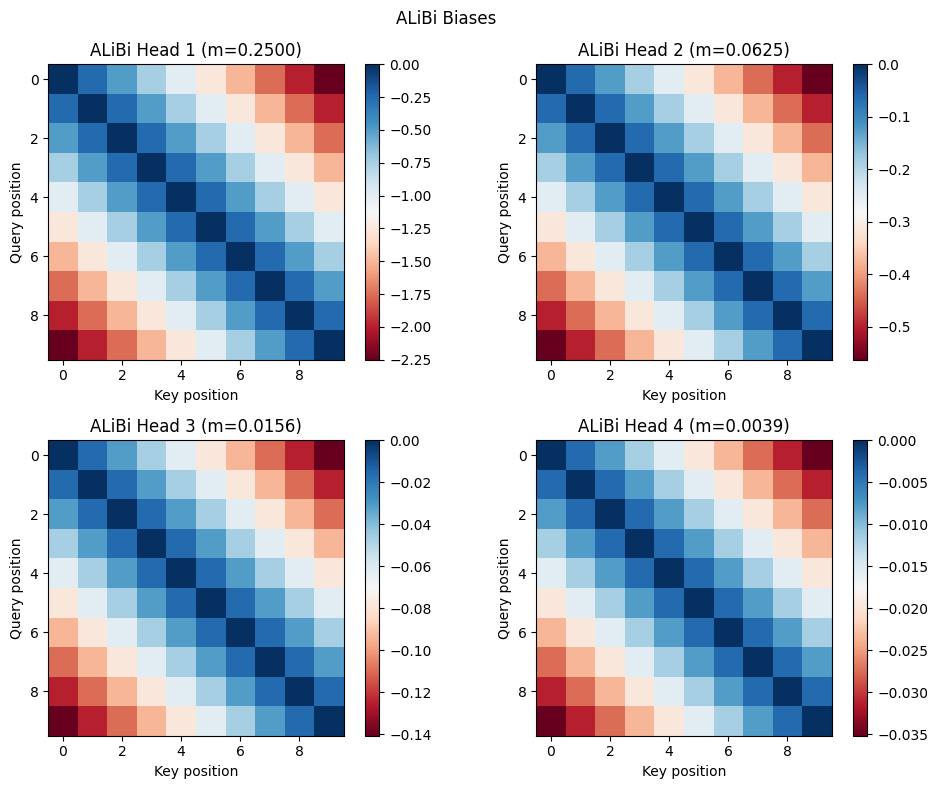

2026-05-31 19:30:22,546 [INFO] positional: ALiBi biases generated for 4 heads


In [9]:
log.debug("Implementing ALiBi for demonstration")

# ALiBi (Press et al., 2021): penalises attention scores by distance instead of adding PE
# scores(i,j) -= |i-j| * m_h, where m_h is a head-specific slope
# No extra parameters; excellent extrapolation to unseen lengths
# Each head has its own slope: large = local attention, small = global
# This is an alternative approach to encoding relative positions
def alibi_bias(n_heads, max_len):
    """
    Generates ALiBi bias.
    Each head gets its own slope m = 2^(-8/h * i)
    """
    slopes = torch.tensor([2 ** (-8 / n_heads * i) for i in range(1, n_heads + 1)])
    positions = torch.arange(max_len).float()
    distance = positions.unsqueeze(0) - positions.unsqueeze(1)  # (max_len, max_len)
    bias = -slopes.view(-1, 1, 1) * distance.abs().unsqueeze(0)  # (n_heads, max_len, max_len)
    return bias

n_heads, max_len = 4, 10
alibi = alibi_bias(n_heads, max_len)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for i, ax in enumerate(axes.flat):
    im = ax.imshow(alibi[i].numpy(), cmap='RdBu')
    ax.set_title(f'ALiBi Head {i+1} (m={2**(-8/n_heads*(i+1)):.4f})')
    ax.set_xlabel('Key position')
    ax.set_ylabel('Query position')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('ALiBi Biases')
plt.tight_layout()
plt.show()
log.info("ALiBi biases generated for %d heads", n_heads)


In [ ]:
print("=== Positional Encodings complete ===")
print("Topics covered:")
print("  - Permutation invariance problem")
print("  - Sinusoidal PE: formulas, implementation, heatmap")
print("  - PositionalEncoding module")
print("  - Learnable PE (BERT-style)")
print("  - Comparison: sinusoidal vs learnable")
print("  - How PE affects attention patterns")
print("  - Relative PE approaches: T5, ALiBi, RoPE")
print("  - ALiBi implementation demo")
log.info("Positional encodings notebook complete")

## References

- Vaswani et al. (2017). *Attention Is All You Need*. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)
- Press et al. (2021). *ALiBi: Train Short, Test Long*. [arXiv:2108.12409](https://arxiv.org/abs/2108.12409)
- Su et al. (2021). *RoFormer: Enhanced Transformer with Rotary Position Embedding*. [arXiv:2104.09864](https://arxiv.org/abs/2104.09864)
- Raffel et al. (2020). *Exploring the Limits of Transfer Learning with T5*. [arXiv:1910.10683](https://arxiv.org/abs/1910.10683)
